# [0.1] DESI Data: Import a Subset


In [2]:
import os
import fitsio
import numpy as np
from tqdm import tqdm
from pathlib import Path
from astropy.io import fits
from astropy.table import join, Table
import pandas as pd
import nested_pandas as npd
import matplotlib.pyplot as plt
import glob
import pyarrow as pa
import lsdb
from hats.io.validation import is_valid_catalog
from hats_import.catalog.file_readers import InputReader
from hats_import.pipeline import pipeline_with_client
from hats_import.catalog.arguments import ImportArguments
from dask.distributed import Client

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
main_directory = Path("/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron")
core_redshift_catalog = main_directory / "zcatalog/v1/zall-pix-iron.fits"
spectra_directory = main_directory / "healpix/"

## Set up

**Where will the product live?** 
- Unsure. 
- In my notes' Background section, I mention a USDF dir `/sdf/data/rubin/cosmicdata/lsdb` where we want to "transfer (nearly) all HATS catalogs that are on data.lsdb.io"
- But in Stephen Bailey's email, he mentions two dirs:
    - `/global/cfs/cdirs/cosmo/users/` for testing (make your own user dir here)
    - `/global/cfs/cdirs/cosmo/www/users/` for dir you want to make web visible

Let's target the dir that Stephen talked about, especially for this initial subset. And recall, we have an honor-system imposed 50TB limit here.

In [30]:
users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"
os.makedirs(target_user_dir, exist_ok=True)

! tree -L 2 $users_dir

/global/cfs/cdirs/cosmo/users
├── cosmo
│   ├── archive_unwise_neo11.log
│   └── archive_unwise_neo9.log
├── olynn
│   └── desi-dr1-test
├── sjbailey
│   ├── dev
│   └── git
└── xiangchl
    ├── DP1
    ├── pdr3_dud_rev
    └── pdr3_wide

10 directories, 2 files


In [31]:
# Set up paths and arguments for the HATS import pipeline run.

base_path = spectra_directory
output_path = target_user_dir

print(f"Base path for input files: {base_path}")
print(f"Output path for HATS import: {output_path}")

Base path for input files: /global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix
Output path for HATS import: /global/cfs/cdirs/cosmo/users/olynn


## Build out what we'd like in our read() method
Demo the logic we'd like to put into the read method of our custom InputReader

In [22]:
print(spectra_directory)

# spectra_file = spectra_directory / "main/dark/0/0/spectra-main-dark-0.fits.gz"
redrock_file = spectra_directory / "main/dark/0/0/redrock-main-dark-0.fits"
coadd_file = spectra_directory / "main/dark/0/0/coadd-main-dark-0.fits"


/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix


In [15]:
FIBERMAP_COLUMNS = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS',
    'COADD_NUMEXP',       # number of exposures combined
    'COADD_EXPTIME',      # total exposure time
    'COADD_NUMNIGHT',     # number of nights
    'COADD_NUMTILE',      # number of tiles
    'MEAN_FIBER_RA', 'MEAN_FIBER_DEC',  # mean fiber position
    'MEAN_PSF_TO_FIBER_SPECFLUX',
]
redrock_columns = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']


with fits.open(coadd_file, memmap=True) as hdul:
    fibermap = Table(hdul['FIBERMAP'].data)[FIBERMAP_COLUMNS].to_pandas()

with fits.open(redrock_file, memmap=True) as hdul:
    redshifts = Table(hdul['REDSHIFTS'].data)[redrock_columns].to_pandas()

# join on TARGETID, use TARGETID as index for join_nested alignment
joined = fibermap.merge(redshifts, on='TARGETID', how='left')
joined = npd.NestedFrame(joined.set_index('TARGETID'))

# add one nested column per camera
with fits.open(coadd_file, memmap=True) as hdul:
    for cam in ['B', 'R', 'Z']:
        wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')  # float64, native endian
        flux = hdul[f'{cam}_FLUX'].data.astype('f4')        # float32, native endian
        ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
        mask = hdul[f'{cam}_MASK'].data.astype('i4')        # int32, native endian

        n_wave = len(wave)
        n_targets = len(joined)
        target_ids = joined.index

        flat = pd.DataFrame({
            'wavelength': np.tile(wave, n_targets),
            'flux':       flux.ravel(),
            'ivar':       ivar.ravel(),
            'mask':       mask.ravel(),
        }, index=np.repeat(target_ids, n_wave))

        joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

In [16]:
# Idk if this is because I'm using this notebook by sshing into nersc through my IDE, or it's always like this on NERSC, but the 
# standard display of frames is just plain text and I simply will not stand for that; so, we use .style.format()

joined[:3].style.format()

,TARGET_RA,TARGET_DEC,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,EBV,MORPHTYPE,PHOTSYS,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_PSF_TO_FIBER_SPECFLUX,Z,ZERR,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,spectra_b,spectra_r,spectra_z
TARGETID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
39627791519454588,44.925441,0.149561,262148,0,0,0,3.500351,6.499963,8.481231,9.281976,11.241416,1296.395874,808.495850,195.674805,2.429977,0.624285,0.082197,PSF,S,5,5773.509277,4,4,44.925449,0.149569,0.789000,0.000010,0.000004,0,3633.518637,STAR,K,wavelength flux ivar mask 0 3600.0 -0.806199 0.400130 0 1 3600.8 2.058855 0.461011 0 ... ... ... ... ... 2749 5799.2 3.907246 13.640164 0 2750 5800.0 3.664724 16.140446 0 [2751 rows x 4 columns],wavelength flux ivar mask 0 5760.0 5.079622 7.327995 0 1 5760.8 3.517563 4.691791 0 ... ... ... ... ... 2324 7619.2 3.325952 2.924737 0 2325 7620.0 4.099898 3.609118 0 [2326 rows x 4 columns],wavelength flux ivar mask 0 7520.0 3.271897 17.164492 0 1 7520.8 4.382219 17.904621 0 ... ... ... ... ... 2879 9823.2 2.803348 53.470886 0 2880 9824.0 2.921397 56.222870 0 [2881 rows x 4 columns]
39627791519452760,44.872364,0.256157,655394,0,0,0,0.473666,0.693162,1.390630,0.554141,-1.799120,1779.620850,1118.055298,164.911484,3.290879,0.689016,0.083015,REX,S,2,2268.991699,1,1,44.872396,0.256173,0.781874,0.907971,0.000028,0,393.729365,GALAXY,,wavelength flux ivar mask 0 3600.0 -3.239104 0.145341 0 1 3600.8 3.484088 0.153856 0 ... ... ... ... ... 2749 5799.2 0.415306 4.903719 0 2750 5800.0 -0.181315 6.398905 0 [2751 rows x 4 columns],wavelength flux ivar mask 0 5760.0 0.175000 0.322748 0 1 5760.8 -2.540143 0.258060 0 ... ... ... ... ... 2324 7619.2 0.299748 2.135201 0 2325 7620.0 -0.595694 3.010594 0 [2326 rows x 4 columns],wavelength flux ivar mask 0 7520.0 0.195745 7.567543 0 1 7520.8 0.258299 5.262014 0 ... ... ... ... ... 2879 9823.2 -0.197745 17.247189 0 2880 9824.0 0.353072 24.972752 0 [2881 rows x 4 columns]
39627791519456177,44.979791,0.158020,65537,0,0,0,0.291093,1.602971,8.538551,31.935289,17.992620,1574.048096,893.703979,110.301537,2.492457,0.630278,0.086307,DEV,S,2,2268.991699,1,1,44.979811,0.158028,0.780985,0.766289,0.000111,0,428.309324,GALAXY,,wavelength flux ivar mask 0 3600.0 -3.267536 0.144184 0 1 3600.8 -0.200239 0.157363 0 ... ... ... ... ... 2749 5799.2 0.177989 4.983444 0 2750 5800.0 0.118123 6.702578 0 [2751 rows x 4 columns],wavelength flux ivar mask 0 5760.0 0.476041 0.362911 0 1 5760.8 -2.036068 0.297379 0 ... ... ... ... ... 2324 7619.2 0.995480 1.984723 0 2325 7620.0 0.012145 2.131025 0 [2326 rows x 4 columns],wavelength flux ivar mask 0 7520.0 1.225759 7.893283 0 1 7520.8 1.121427 5.382226 0 ... ... ... ... ... 2879 9823.2 0.472292 19.146610 0 2880 9824.0 0.687030 25.947758 0 [2881 rows x 4 columns]


In [17]:
joined['spectra_b'][joined.index[0]]

,wavelength,flux,ivar,mask
0,3600.0,-0.806199,0.400130,0
1,3600.8,2.058855,0.461011,0
...,...,...,...,...
2749,5799.2,3.907246,13.640164,0
2750,5800.0,3.664724,16.140446,0


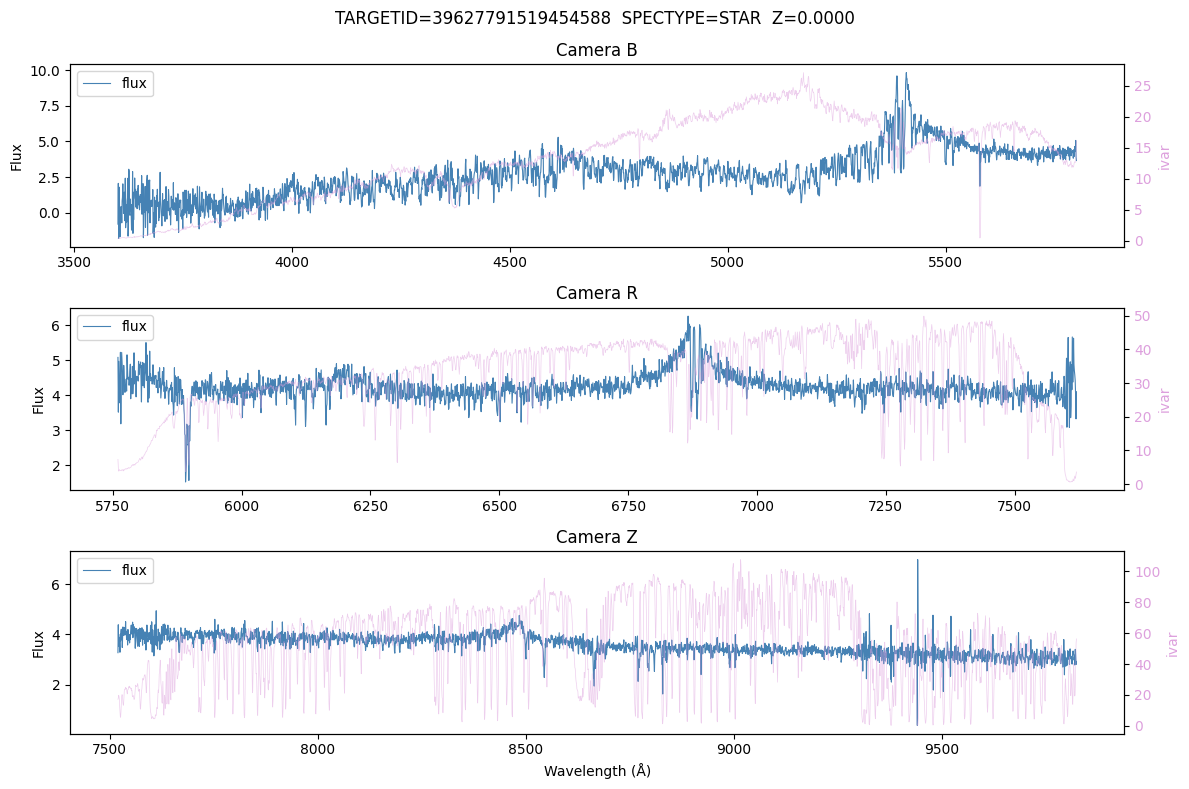

In [18]:
target_idx = 0

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ['steelblue', 'plum']

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ['b', 'r', 'z']):
    # Get the spectrum.
    spec = joined[f'spectra_{cam}'].iloc[target_idx]
    
    # Plot flux on the primary y-axis.
    ax.plot(spec['wavelength'], spec['flux'], lw=0.8, color=colors[0], label='flux')
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec['wavelength'], spec['ivar'], lw=0.5, color=colors[1], alpha=0.5, label='ivar')
    ax_twin.set_ylabel('ivar', color=colors[1])
    ax_twin.tick_params(axis='y', labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel('Flux')
    ax.set_title(f'Camera {cam.upper()}')
    ax.legend(loc='upper left')

# Set x-axis label and overall figure title.
axes[-1].set_xlabel('Wavelength (Å)')
fig.suptitle(f'TARGETID={joined.index[target_idx]}  SPECTYPE={joined["SPECTYPE"].iloc[target_idx]}  Z={joined["Z"].iloc[target_idx]:.4f}')
plt.tight_layout()
plt.show()

<div class="alert alert-info">
<b>ELI5: Inverse Variance</b>

`Inverse variance = 1 / (noise²)`

Think of it as a **confidence score** for each pixel. For each wavelength bin, the detector measured some flux, but that measurement has some uncertainty (noise). Instead of storing the noise directly, DESI stores 1/noise².  

- High ivar → low noise → you can trust this pixel  
- Low ivar → high noise → be skeptical of this pixel  
- ivar = 0 → the pixel is completely bad/masked, don't use it at all  

The reason astronomers use ivar instead of just noise is practical: when you want to combine or fit spectra, the math works out more cleanly with inverse variance. For example, the best estimate of a quantity from noisy data is just a weighted average where the weights are... the inverse variances.  

For DESI specifically you'd expect:  

- Low ivar at the blue edge of B (~3600Å) — detectors are just less sensitive there  
- Low ivar at the red edge of Z (~9800Å) — same reason, plus sky background gets noisy  
- Spikes of ivar=0 scattered throughout — bad pixels, cosmic rays, or bright sky emission lines that got masked  
</div>


## Generalize a tiny bit: run hats-import on 2 fits files
*(Let's show n and n -> n+1)*

Demonstrate we can run this on:
- **group 0 healpix 0**, to show we can run it at all, and
- **group 0 healpix 1**, to show we can run this on more than one input file at a time

In [23]:
# Import and set up dask

from dask.distributed import Client
import socket

# Make a dask client
client = Client(
    n_workers=4,
    memory_limit="4GB",
)
client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 256,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38809,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39129,Total threads: 64
Dashboard: http://127.0.0.1:36105/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:33689,


In [24]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.
username = "olynn"
current_compute_node = socket.gethostname()

print(f"1. In a local terminal, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser at: http://localhost:8787/status")

1. In a local terminal, run: ssh -L 8787:login11:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser at: http://localhost:8787/status


### Define custom input reader

In [37]:
# Revised version:

FIBERMAP_COLUMNS = [
    'TARGETID', 'TARGET_RA', 'TARGET_DEC',
    'DESI_TARGET', 'BGS_TARGET', 'MWS_TARGET', 'SCND_TARGET',
    'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2',
    'FLUX_IVAR_G', 'FLUX_IVAR_R', 'FLUX_IVAR_Z', 'FLUX_IVAR_W1', 'FLUX_IVAR_W2',
    'EBV', 'MORPHTYPE', 'PHOTSYS',
    'COADD_NUMEXP',       # number of exposures combined
    'COADD_EXPTIME',      # total exposure time
    'COADD_NUMNIGHT',     # number of nights
    'COADD_NUMTILE',      # number of tiles
    'MEAN_FIBER_RA', 'MEAN_FIBER_DEC',  # mean fiber position
    'MEAN_PSF_TO_FIBER_SPECFLUX',
]
REDROCK_COLUMNS = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'DELTACHI2', 'SPECTYPE', 'SUBTYPE']

class DesiCoaddReader(InputReader):

    def __init__(self, chunksize=500_000):
        self.chunksize = chunksize

    def read(self, input_file, read_columns=None):
        input_file = str(input_file)
        redrock_file = input_file.replace('coadd-', 'redrock-')

        # read fibermap from coadd (1 row per unique target)
        with fits.open(input_file, memmap=True) as hdul:
            fibermap = Table(hdul['FIBERMAP'].data)[FIBERMAP_COLUMNS].to_pandas()
            fibermap = fibermap.astype({col: fibermap[col].dtype.newbyteorder('=')
                                        for col in fibermap.columns})

        # read redshifts
        with fits.open(redrock_file, memmap=True) as hdul:
            redshifts = Table(hdul['REDSHIFTS'].data)[REDROCK_COLUMNS].to_pandas()
            redshifts = redshifts.astype({col: redshifts[col].dtype.newbyteorder('=')
                                          for col in redshifts.columns})

        # join and set TARGETID as index
        joined = fibermap.merge(redshifts, on='TARGETID', how='left')
        joined = npd.NestedFrame(joined.set_index('TARGETID'))

        # add nested spectra columns from coadd file
        with fits.open(input_file, memmap=True) as hdul:
            for cam in ['B', 'R', 'Z']:
                wave = hdul[f'{cam}_WAVELENGTH'].data.astype('f8')
                flux = hdul[f'{cam}_FLUX'].data.astype('f4')  # (n_targets, n_wave)
                ivar = hdul[f'{cam}_IVAR'].data.astype('f4')
                mask = hdul[f'{cam}_MASK'].data.astype('i4')

                n_wave = len(wave)
                target_ids = joined.index

                flat = pd.DataFrame({
                    'wavelength': np.tile(wave, len(joined)),
                    'flux':       flux.ravel(),
                    'ivar':       ivar.ravel(),
                    'mask':       mask.ravel(),
                }, index=np.repeat(target_ids, n_wave))

                joined = joined.join_nested(flat, f'spectra_{cam.lower()}')

        yield joined


def get_desi_coadd_files(base_path, surveys=('main',), programs=('dark',)):
    """Glob all coadd files across surveys and programs."""
    files = []
    for survey in surveys:
        for program in programs:
            pattern = os.path.join(
                base_path, survey, program, '*', '*',
                f'coadd-{survey}-{program}-*.fits'
            )
            files.extend(glob.glob(pattern))
    return sorted(files)

### Set up & run pipeline

In [ ]:
# # Just healpix group 0, pixels 0 and 1
# test_files = [
#     f'{base_path}/main/dark/0/0/spectra-main-dark-0.fits.gz',
#     f'{base_path}/main/dark/0/1/spectra-main-dark-1.fits.gz',
# ]

# args = ImportArguments(
#     input_file_list=test_files,
#     file_reader=DesiSpectraReader(),
#     ra_column='TARGET_RA',
#     dec_column='TARGET_DEC',
#     output_artifact_name='desi-dr1-test',
#     output_path=output_path,
#     pixel_threshold=5_000,
#     resume=False
# )

In [38]:
# Remove any files in the output directory 
! tree $output_path
! printf "\nRemoving files...\n\n"
! rm -rf $output_path/*
! tree $output_path

/global/cfs/cdirs/cosmo/users/olynn
└── desi-dr1-coadd-test
    └── intermediate
        ├── input_paths.txt
        ├── reader.pickle
        ├── reducing
        ├── row_count_histograms
        └── splitting

5 directories, 2 files

Removing files...

/global/cfs/cdirs/cosmo/users/olynn

0 directories, 0 files


In [39]:
base_path = '/global/cfs/cdirs/desi/public/dr1/spectro/redux/iron/healpix'

test_files = [
    f'{base_path}/main/dark/0/0/coadd-main-dark-0.fits',
    f'{base_path}/main/dark/0/1/coadd-main-dark-1.fits',
]

args = ImportArguments(
    input_file_list=test_files,
    file_reader=DesiCoaddReader(),
    ra_column='TARGET_RA',
    dec_column='TARGET_DEC',
    output_artifact_name='desi-dr1-coadd-test',
    output_path=output_path,
    pixel_threshold=5_000,
    resume=False,
)

with Client(n_workers=2, threads_per_worker=1) as client:
    pipeline_with_client(args, client)

/global/homes/o/olynn/.venvs/p312/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43869 instead
  warnings.warn(


Catalog: Finishing : 100%|██████████| 6/6 [00:00<00:00, 38.38it/s]


### Check the imported catalog

In [40]:
! tree $output_path

/global/cfs/cdirs/cosmo/users/olynn
└── desi-dr1-coadd-test
    ├── dataset
    │   ├── _common_metadata
    │   ├── _metadata
    │   └── Norder=5
    │       └── Dir=0
    │           └── Npix=0.parquet
    ├── hats.properties
    ├── partition_info.csv
    ├── point_map.fits
    ├── properties
    └── skymap.fits

4 directories, 8 files


In [41]:
output_catalog = output_path / "desi-dr1-coadd-test"

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

Validating catalog at path /global/cfs/cdirs/cosmo/users/olynn/desi-dr1-coadd-test ... 
Found 1 partitions.
Approximate coverage is 0.01 % of the sky.


True

In [42]:
desi_dr1_test_cat = lsdb.open_catalog(output_catalog)
desi_dr1_test_cat

,TARGETID,TARGET_RA,TARGET_DEC,DESI_TARGET,BGS_TARGET,MWS_TARGET,SCND_TARGET,FLUX_G,FLUX_R,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,EBV,MORPHTYPE,PHOTSYS,COADD_NUMEXP,COADD_EXPTIME,COADD_NUMNIGHT,COADD_NUMTILE,MEAN_FIBER_RA,MEAN_FIBER_DEC,MEAN_PSF_TO_FIBER_SPECFLUX,Z,ZERR,ZWARN,DELTACHI2,SPECTYPE,SUBTYPE,spectra_b,spectra_r,spectra_z
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 5, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],int64[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],string[pyarrow],int16[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],double[pyarrow],string[pyarrow],string[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."


In [43]:
# Okay, that's a lot of columns. TODO: specify default columns--in the catalog itself?

desi_dr1_test_cat = lsdb.open_catalog(output_catalog, columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z', 'SPECTYPE', 'spectra_b', 'spectra_r', 'spectra_z'])
desi_dr1_test_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,SPECTYPE,spectra_b,spectra_r,spectra_z
npartitions=1,,,,,,,,
"Order: 5, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],string[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."


In [44]:
df = desi_dr1_test_cat.head(5)
df

TARGETID  TARGET_RA  TARGET_DEC         Z SPECTYPE  \
_healpix_29                                                                 
24531778214   39627785483846048  45.014136    0.019739  1.308415      QSO   
76347715933   39627785483846390  45.027565    0.029181  0.884491   GALAXY   
79430617729    2714981116149760  45.018964    0.029766  0.129609   GALAXY   
88592216842          -110547443  45.028689    0.031667  1.499465   GALAXY   
101138674798  39627785483846478  45.030526    0.041094  1.263249   GALAXY   

                                                      spectra_b  \
_healpix_29                                                       
24531778214   [{wavelength: 3600.0, flux: 2.924896, ivar: 0....   
76347715933   [{wavelength: 3600.0, flux: -3.560856, ivar: 0...   
79430617729   [{wavelength: 3600.0, flux: -5.12881, ivar: 0....   
88592216842   [{wavelength: 3600.0, flux: 1.824267, ivar: 0....   
101138674798  [{wavelength: 3600.0, flux: 0.314766, ivar: 0....   

                                                      spectra_r  \
_healpix_29                                                       
24531778214   [{wavelength: 5760.0, flux: 1.965631, ivar: 7....   
76347715933   [{wavelength: 5760.0, flux: 0.741585, ivar: 0....   
79430617729   [{wavelength: 5760.0, flux: 0.757192, ivar: 0....   
88592216842   [{wavelength: 5760.0, flux: -0.888818, ivar: 1...   
101138674798  [{wavelength: 5760.0, flux: 0.615158, ivar: 3....   

                                                      spectra_z  
_healpix_29                                                      
24531778214   [{wavelength: 7520.0, flux: 0.379682, ivar: 23...  
76347715933   [{wavelength: 7520.0, flux: -0.305626, ivar: 5...  
79430617729   [{wavelength: 7520.0, flux: 0.227893, ivar: 10...  
88592216842   [{wavelength: 7520.0, flux: -0.377297, ivar: 4...  
101138674798  [{wavelength: 7520.0, flux: 1.088948, ivar: 11...

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Points in the desi-dr1-coadd-test catalog'}>)

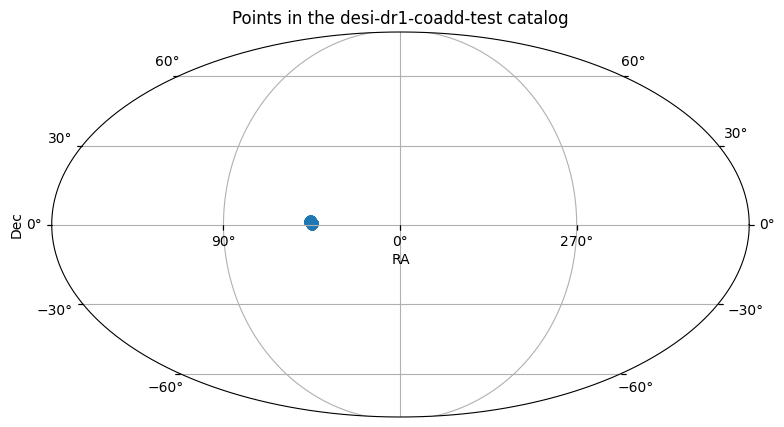

In [45]:
desi_dr1_test_cat.plot_points()